633834
7984179
4300046


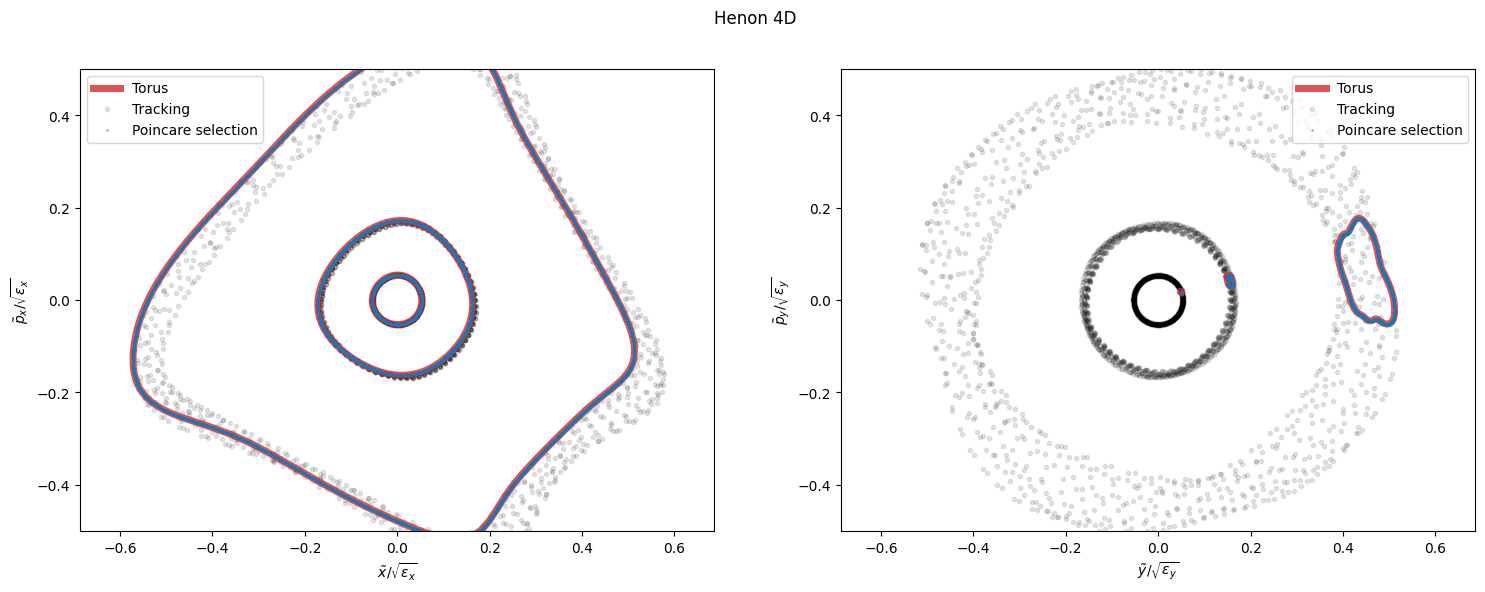

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sciStat
import nafflib

import sys
sys.path.append('/Users/pbelanger/ABPLocal/pytori')
import pytori.torus as pytorus




# Henon parameters:
# ---
nturns = int(1e6)
# points = np.array([0.1,0.2,0.3,0.4,0.41,0.45,0.51,0.555])
# points = np.array([0.4])
points = np.array([0.05,0.15,0.4])[::-1]

slope  = 0.35

coupling = 0.25
Qx_list = [0.2064898024701758,0.2264898024701758, (3 - np.sqrt(5)) / 2]
Qx = 0.24464898024701758
Qy = np.sqrt(2) - 1
# ------------

particles = []
for point in points:
    
    # Tracking
    x,px,y,py = nafflib.henon_map_4D(point,slope*point,point,slope*point,   Qx = Qx,
                                                                            Qy = Qy,
                                                                            coupling = coupling,
                                                                            num_turns= nturns)
    # Saving
    dct = {'x':x,'px':px,'y':y,'py':py}
    particles.append(dct)


n_harm = 126
from fractions import Fraction
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle('Henon 4D')
for p_idx,part in enumerate(particles):
    
    fundamental_tunes = [nafflib.tune(part[plane][:int(5e4)],part[f'p{plane}'][:int(5e4)],window_order=4) for plane in ['x','y']]

    N_start = 0

    supersampling = np.arange(1,int(1e7))
    superperiod = int(supersampling[np.argmin(np.abs(np.round(supersampling*fundamental_tunes[1])-supersampling*fundamental_tunes[1]))])
    print(superperiod)
    N_r = np.arange(int(1e4))*superperiod

    Ax,Qx  = nafflib.harmonics( part['x'][:int(5e4)],part[f'px'][:int(5e4)],num_harmonics = n_harm,window_order=4)
    Cx,err,_f = nafflib.find_linear_combinations(Qx,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
    # x_r,px_r = nafflib.generate_pure_KAM(amplitudes, combi, fundamental_tunes, N_r)
    x_r,px_r = nafflib.generate_signal(Ax,Qx, N_start + N_r)

    Ay,Qy  = nafflib.harmonics( part['y'][:int(5e4)],part[f'py'][:int(5e4)],num_harmonics = n_harm,window_order=4)
    Cy,err,_f = nafflib.find_linear_combinations(Qy,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
    # combi,err,_f = nafflib.find_linear_combinations(frequencies,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
    # y_r,py_r = nafflib.generate_pure_KAM(amplitudes, combi, fundamental_tunes,N_r)
    y_r,py_r = nafflib.generate_signal(Ay,Qy, N_start + N_r)


    mytorus = pytorus.Torus(Ax,Ay,Cx,Cy)
    

    theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,1000)
    theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start
    

    slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
    slice_x,slice_y = slice_x[0],slice_y[0]



    plt.sca(axes[0])
    plt.plot(slice_x[:,0],slice_x[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    plt.plot(x_r,px_r,'.',ms=2,color='C0',alpha=0.4)

    plt.sca(axes[1])
    plt.plot(slice_y[:,0],slice_y[:,1],'-',lw=5,color='C3',alpha=0.8,zorder=-10)
    plt.plot(y_r,py_r,'.',ms=2,color='C0',alpha=0.4)


    for plane,ax in zip(['x','y'],axes):
        plt.sca(ax)
        plt.plot(part[plane][:1000],part[f'p{plane}'][:1000],'.',color='k',alpha=0.1,zorder=-20)

        #  Ix = np.mean(part[plane][:1000],part[f'p{plane}'][:1000])
        # plt.plot(np.sqrt(Ix)/2*np.cos(theta_vec),np.sqrt(Ix)/2*np.sin(theta_vec),'-',lw=5,color='k',alpha=0.8,zorder=-10)


    # # SAVE
    # #===============================
    # mesh = mytorus.to_mesh('x',num_angles=500,num_slices=200,r_forced=3,scale_transverse=0.97)
    # mesh['main'].meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    # mesh['sec'].meta['x-px']  = [[_x,_px,0] for _x,_px in zip(part['y'][:1000],part['py'][:1000])]

    # main_path,sec_path = mytorus.draw_path('x',Qx=fundamental_tunes[0],Qy=fundamental_tunes[1],N = np.arange(1000),r_forced=3)
    # mesh['main'].meta['draw_path'] = main_path
    # mesh['sec'].meta['draw_path'] = sec_path
    # # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]


    # # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    # mesh['main'].to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X.json')
    # mesh['sec'].to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X_coupling.json')
    # #===============================

# Adding labels
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.axis('equal')
    if plane == 'zeta':
        plane = '\zeta'
    plt.xlabel(rf'$\tilde {plane}/\sqrt{{\varepsilon_{plane}}}$')
    plt.ylabel(rf'$\tilde p_{plane}/\sqrt{{\varepsilon_{plane}}}$')

    plt.plot(np.nan,np.nan,'-',lw=5,color='C3',alpha=0.8,zorder=-10,label='Torus')
    plt.plot(np.nan,np.nan,'.',color='k',alpha=0.1,label='Tracking')
    plt.plot(np.nan,np.nan,'.',ms=2,color='C0',alpha=0.4,label='Poincare selection')

    plt.legend()

    plt.xlim(-0.5,0.5)
    plt.ylim(-0.5,0.5)


plt.sca(axes[0])
# plt.xlim(-0.5,-0.25)
# plt.ylim(0,0.2)



In [7]:
Ax,Qx  = nafflib.harmonics( part['x'][:int(5e4)],part[f'px'][:int(5e4)],num_harmonics = n_harm,window_order=4)
Cx,err,_f = nafflib.find_linear_combinations(Qx,fundamental_tunes=fundamental_tunes,max_harmonic_order=60)

In [10]:
n_harm

126

In [8]:
Cx

[(1, 0, 0),
 (0, 0, 0),
 (2, 0, 0),
 (-2, 0, 0),
 (0, -2, 1),
 (-3, 0, 1),
 (0, 2, -1),
 (1, -2, 1),
 (3, 0, -1),
 (-1, 0, 0),
 (1, 2, -1),
 (-1, 2, -1),
 (-1, -2, 1),
 (-4, 0, 1),
 (4, 0, -1),
 (-2, 2, 0),
 (5, 0, -1),
 (2, 2, -1),
 (2, -2, 0),
 (-2, -2, 1),
 (0, -4, 2),
 (-3, 2, 0),
 (-5, 0, 1),
 (3, -2, 0),
 (0, 4, -2),
 (-3, -2, 2),
 (6, 0, -1),
 (3, 2, -2),
 (-6, 0, 1),
 (4, -2, 0),
 (-1, 4, -1),
 (1, -4, 1),
 (-4, -2, 2),
 (-4, 2, 0),
 (-7, 0, 2),
 (-1, -4, 2),
 (-2, 4, -1),
 (1, 4, -2),
 (4, 2, -2),
 (5, -2, 0),
 (2, -4, 1),
 (7, 0, -2),
 (-5, 2, 0),
 (5, 2, -2),
 (-5, -2, 2),
 (-8, 0, 2),
 (-1, 6, -2),
 (8, 0, -2),
 (3, -4, 1),
 (2, 4, -2),
 (-3, 4, -1),
 (-6, 2, 1),
 (3, 4, -2),
 (-2, -4, 2),
 (0, 6, -2),
 (0, -6, 2),
 (9, 0, -2),
 (-3, -4, 2),
 (6, -2, -1),
 (4, -4, 1),
 (2, -6, 2),
 (-2, 6, -2),
 (3, -6, 2),
 (-7, 2, 1),
 (6, 2, -2),
 (-9, 0, 2),
 (7, -2, -1),
 (1, -6, 2),
 (-4, 4, -1),
 (-4, -4, 3),
 (-1, -6, 3),
 (4, 4, -3),
 (10, 0, -2),
 (-6, -2, 2),
 (-10, 0, 2),
 (-8, 

In [5]:
N = np.arange(100)
2*np.pi*fundamental_tunes[0]*N

array([  0.        ,   1.53687795,   3.0737559 ,   4.61063384,
         6.14751179,   7.68438974,   9.22126769,  10.75814564,
        12.29502359,  13.83190153,  15.36877948,  16.90565743,
        18.44253538,  19.97941333,  21.51629128,  23.05316922,
        24.59004717,  26.12692512,  27.66380307,  29.20068102,
        30.73755896,  32.27443691,  33.81131486,  35.34819281,
        36.88507076,  38.42194871,  39.95882665,  41.4957046 ,
        43.03258255,  44.5694605 ,  46.10633845,  47.64321639,
        49.18009434,  50.71697229,  52.25385024,  53.79072819,
        55.32760614,  56.86448408,  58.40136203,  59.93823998,
        61.47511793,  63.01199588,  64.54887383,  66.08575177,
        67.62262972,  69.15950767,  70.69638562,  72.23326357,
        73.77014151,  75.30701946,  76.84389741,  78.38077536,
        79.91765331,  81.45453126,  82.9914092 ,  84.52828715,
        86.0651651 ,  87.60204305,  89.138921  ,  90.67579894,
        92.21267689,  93.74955484,  95.28643279,  96.82

In [3]:
np.linspace(0,2*np.pi,100)

array([0.        , 0.06346652, 0.12693304, 0.19039955, 0.25386607,
       0.31733259, 0.38079911, 0.44426563, 0.50773215, 0.57119866,
       0.63466518, 0.6981317 , 0.76159822, 0.82506474, 0.88853126,
       0.95199777, 1.01546429, 1.07893081, 1.14239733, 1.20586385,
       1.26933037, 1.33279688, 1.3962634 , 1.45972992, 1.52319644,
       1.58666296, 1.65012947, 1.71359599, 1.77706251, 1.84052903,
       1.90399555, 1.96746207, 2.03092858, 2.0943951 , 2.15786162,
       2.22132814, 2.28479466, 2.34826118, 2.41172769, 2.47519421,
       2.53866073, 2.60212725, 2.66559377, 2.72906028, 2.7925268 ,
       2.85599332, 2.91945984, 2.98292636, 3.04639288, 3.10985939,
       3.17332591, 3.23679243, 3.30025895, 3.36372547, 3.42719199,
       3.4906585 , 3.55412502, 3.61759154, 3.68105806, 3.74452458,
       3.8079911 , 3.87145761, 3.93492413, 3.99839065, 4.06185717,
       4.12532369, 4.1887902 , 4.25225672, 4.31572324, 4.37918976,
       4.44265628, 4.5061228 , 4.56958931, 4.63305583, 4.69652

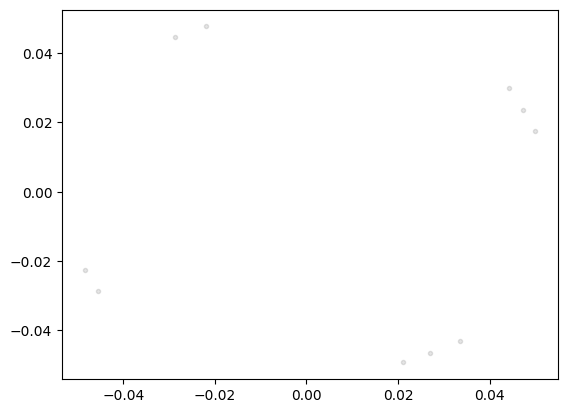

In [15]:
N = np.arange(10)
Qx = fundamental_tunes[0]
Qy = fundamental_tunes[1]

Thetax = 2*np.pi*Qx*N
Thetay = 2*np.pi*Qy*N

main = [mytorus.projection('x',Thetax[[i]],Thetay[[i]],r_forced=3)[0][0,0] for i in range(len(N))]


plt.figure()
plane = 'x'
plt.plot(part[plane][:10],part[f'p{plane}'][:10],'.',color='k',alpha=0.1,zorder=-20)
plt.plot()

In [16]:
main 

[array([3.05  , 0.    , 0.0175]),
 array([-2.59270871,  1.55066866, -0.04932045]),
 array([ 1.39629126, -2.60039815, -0.02268598]),
 array([0.13765926, 2.97483768, 0.04772927]),
 array([-1.68339727, -2.54019489,  0.02358437]),
 array([ 2.73019464,  1.30716782, -0.04648131]),
 array([-2.94186889,  0.27285155, -0.02853281]),
 array([ 2.39836397, -1.75418289,  0.04456933]),
 array([-1.18625445,  2.80350463,  0.03008601]),
 array([-0.41947214, -3.00435265, -0.04304652])]

In [14]:
main

[array([3.05  , 0.    , 0.0175]),
 array([-2.59270871,  1.55066866, -0.04932045]),
 array([ 1.39629126, -2.60039815, -0.02268598]),
 array([0.13765926, 2.97483768, 0.04772927]),
 array([-1.68339727, -2.54019489,  0.02358437]),
 array([ 2.73019464,  1.30716782, -0.04648131]),
 array([-2.94186889,  0.27285155, -0.02853281]),
 array([ 2.39836397, -1.75418289,  0.04456933]),
 array([-1.18625445,  2.80350463,  0.03008601]),
 array([-0.41947214, -3.00435265, -0.04304652])]

In [2]:

def draw_path(torus,plane,Qx,Qy,N,r_aspect = None,r_forced = None):
    # ORDER PLANES
    #------------------------
    Thetax = 2*np.pi*Qx*N
    Thetay = 2*np.pi*Qy*N

    points = projection(self,plane,Thetax,Thetay,r_aspect = None,r_forced = None,scale_transverse=1)
        #------------------------

array([ 5.00000000e-02,  2.10448060e-02, -4.84411195e-02, -2.19789594e-02,
        4.73622135e-02,  2.69870277e-02, -4.55050310e-02, -2.85849592e-02,
        4.41481292e-02,  3.34949637e-02, -4.09100210e-02, -3.50790998e-02,
        3.90648890e-02,  3.86922670e-02, -3.51439640e-02, -3.98206715e-02,
        3.38629711e-02,  4.27063486e-02, -2.98576616e-02, -4.43136606e-02,
        2.87060157e-02,  4.70616432e-02, -2.35738053e-02, -4.87025341e-02,
        2.19609262e-02,  5.02345675e-02, -1.61412987e-02, -5.10864740e-02,
        1.49966035e-02,  5.16849016e-02, -9.50166632e-03, -5.25905651e-02,
        8.68257621e-03,  5.31985814e-02, -2.64546455e-03, -5.40475269e-02,
        1.28123429e-03,  5.38335949e-02,  5.21574033e-03, -5.35535616e-02,
       -6.40398131e-03,  5.24671988e-02,  1.21088252e-02, -5.17328000e-02,
       -1.29157078e-02,  5.08922109e-02,  1.84371113e-02, -5.00121154e-02,
       -1.98474532e-02,  4.88910580e-02,  2.55232190e-02, -4.67244743e-02,
       -2.70572524e-02,  

---
# Export for Blender
---

In [2]:
main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=100,r_forced=5)
main_mesh.to_json('data/TORUS_001_X.json')


---
# Matplotlib tests
---

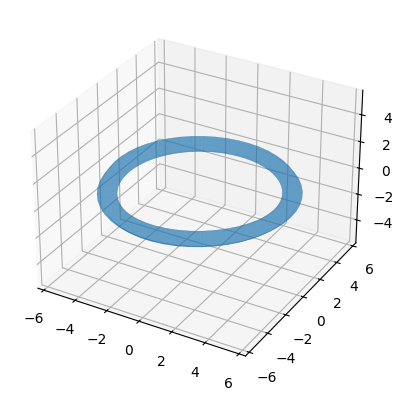

In [3]:

main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=50,r_forced=5)

main_mesh.to_pickle('torus_henon.pkl')
main_mesh.to_json('torus_henon.json')



main_mesh = mytorus.to_mesh('x',num_angles=200,num_slices=50,r_forced=5)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Generate the polygons for each face

poly3d = [[main_mesh.verts[vert_id] for vert_id in face] for face in main_mesh.faces]

# Create a Poly3DCollection object
collection = Poly3DCollection(poly3d, edgecolors='k', linewidths=0, alpha=0.5)
ax.add_collection3d(collection)

# Corrected auto scaling
scale = np.concatenate(main_mesh.verts).flatten()  # Corrected here
ax.auto_scale_xyz(scale, scale, scale)

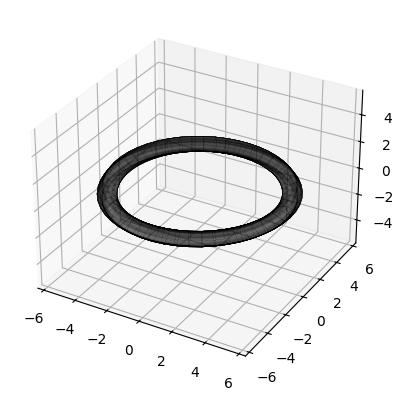

In [4]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

verts = main_mesh.verts
faces = main_mesh.faces

# Create lines for the wireframe
edges = set()
for face in faces:
    face_edges = [(face[i], face[(i+1) % len(face)]) for i in range(len(face))]
    for edge in face_edges:
        edges.add(tuple(sorted(edge)))  # Add each edge as a sorted tuple to avoid duplicates

# Convert edge vertices to line segments for plotting
lines = [[verts[edge[0]], verts[edge[1]]] for edge in edges]

# Create a Line3DCollection from the lines
line_collection = Line3DCollection(lines, colors='k', linewidths=0.1)

# Add the collection to the plot
ax.add_collection(line_collection)

# # Setting the limits to frame the wireframe (might need adjusting)
# ax.set_xlim([verts[:,0].min(), verts[:,0].max()])
# ax.set_ylim([verts[:,1].min(), verts[:,1].max()])
# ax.set_zlim([verts[:,2].min(), verts[:,2].max()])
ax.auto_scale_xyz(scale, scale, scale)

plt.show()

In [21]:
%matplotlib widget

633834
0.7301421260068325 0.017324817203122633 0.7474669432099551
633834
0.7181265270616723 0.005299403339806287 0.7234259304014786


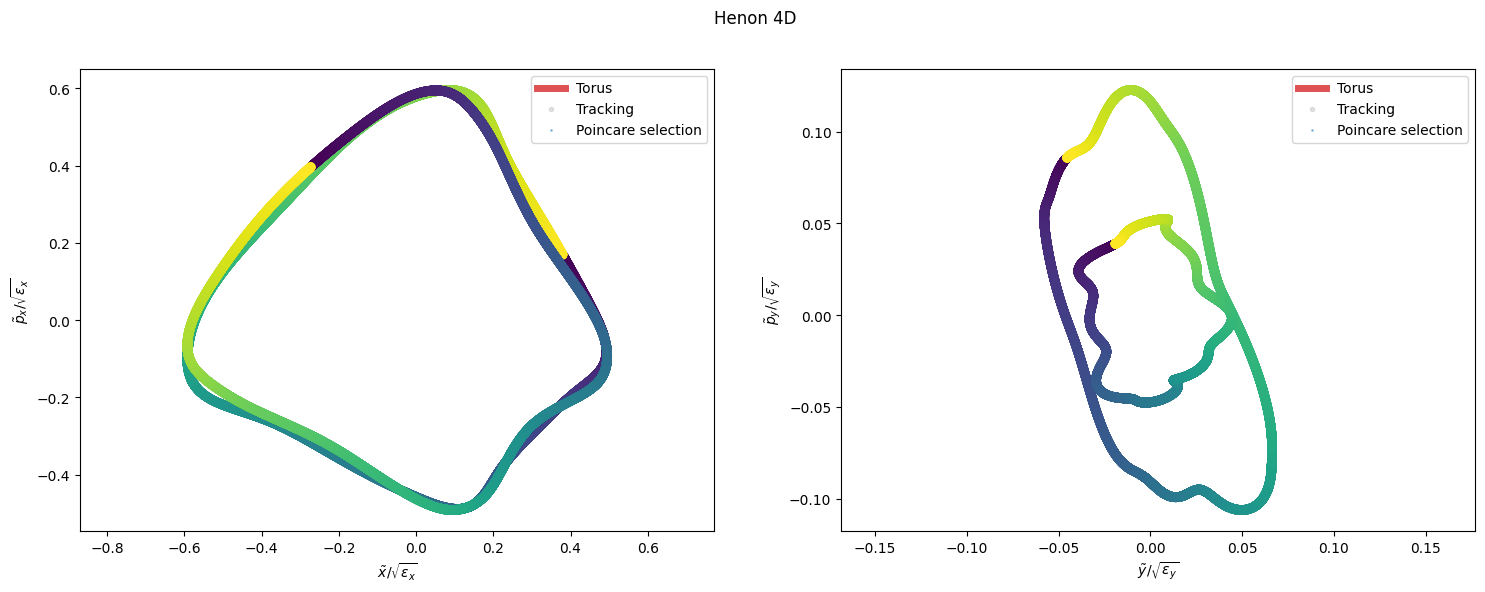

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sciStat
import nafflib

import sys
sys.path.append('/Users/pbelanger/ABPLocal/pytori')
import pytori.torus as pytorus




# Henon parameters:
# ---
nturns = int(1e6)
# points = np.array([0.1,0.2,0.3,0.4,0.41,0.45,0.51,0.555])
# points = np.array([0.4])
points = np.array([0.05,0.15,0.4])[::-1][:1]

slope  = 0.35

coupling = 0.25
Qx_list = [0.2064898024701758,0.2264898024701758, (3 - np.sqrt(5)) / 2]
Qx = 0.24464898024701758
Qy = np.sqrt(2) - 1
# ------------

particles = []
for point in points:
    
    # Tracking
    x,px,y,py = nafflib.henon_map_4D(point,slope*point,point,slope*point,   Qx = Qx,
                                                                            Qy = Qy,
                                                                            coupling = coupling,
                                                                            num_turns= nturns)
    # Saving
    dct = {'x':x,'px':px,'y':y,'py':py}
    particles.append(dct)

# x_area
n_harm = 200
from fractions import Fraction
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle('Henon 4D')
for p_idx,part in enumerate(particles):
    
    fundamental_tunes = [nafflib.tune(part[plane][:int(5e4)],part[f'p{plane}'][:int(5e4)],window_order=4) for plane in ['x','y']]

    for N_start in [0,3]:
    # N_start = 3

        supersampling = np.arange(1,int(1e7))
        superperiod = int(supersampling[np.argmin(np.abs(np.round(supersampling*fundamental_tunes[1])-supersampling*fundamental_tunes[1]))])
        print(superperiod)
        N_r = np.arange(int(1e4))*superperiod

        Ax,Qx  = nafflib.harmonics( part['x'][:int(5e4)],part[f'px'][:int(5e4)],num_harmonics = n_harm,window_order=4)
        Cx,err,_f = nafflib.find_linear_combinations(Qx,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
        # x_r,px_r = nafflib.generate_pure_KAM(amplitudes, combi, fundamental_tunes, N_r)
        x_r,px_r = nafflib.generate_signal(Ax,Qx, N_start + N_r)

        Ay,Qy  = nafflib.harmonics( part['y'][:int(5e4)],part[f'py'][:int(5e4)],num_harmonics = n_harm,window_order=4)
        Cy,err,_f = nafflib.find_linear_combinations(Qy,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
        # combi,err,_f = nafflib.find_linear_combinations(frequencies,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)
        # y_r,py_r = nafflib.generate_pure_KAM(amplitudes, combi, fundamental_tunes,N_r)
        y_r,py_r = nafflib.generate_signal(Ay,Qy, N_start + N_r)


        mytorus = pytorus.Torus(Ax,Ay,Cx,Cy)
        

        theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,10000)
        theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start
        

        slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
        slice_x,slice_y = slice_x[0],slice_y[0]



        plt.sca(axes[0])
        plt.plot(slice_x[:,0]-np.mean(slice_x[:,0]),slice_x[:,1]-np.mean(slice_x[:,1]),'-',lw=2,alpha=0.8,zorder=-10)
        plt.scatter(slice_x[:,0]-np.mean(slice_x[:,0]),slice_x[:,1]-np.mean(slice_x[:,1]),c=theta_vec)
        # plt.plot(x_r-np.mean(slice_x[:,0]),px_r-np.mean(slice_x[:,1]),'.',ms=2,color='C0',alpha=0.4)

        plt.sca(axes[1])
        plt.plot(slice_y[:,0]-np.mean(slice_y[:,0]),slice_y[:,1]-np.mean(slice_y[:,1]),'-',lw=2,alpha=0.8,zorder=-10)
        plt.scatter(slice_y[:,0]-np.mean(slice_y[:,0]),slice_y[:,1]-np.mean(slice_y[:,1]),c=theta_vec)
        # plt.plot(y_r-np.mean(slice_y[:,0]),py_r-np.mean(slice_y[:,1]),'.',ms=2,color='C0',alpha=0.4)


    # for plane,ax in zip(['x','y'],axes):
    #     plt.sca(ax)
    #     plt.plot(part[plane][:1000],part[f'p{plane}'][:1000],'.',color='k',alpha=0.1,zorder=-20)

    #     #  Ix = np.mean(part[plane][:1000],part[f'p{plane}'][:1000])
    #     # plt.plot(np.sqrt(Ix)/2*np.cos(theta_vec),np.sqrt(Ix)/2*np.sin(theta_vec),'-',lw=5,color='k',alpha=0.8,zorder=-10)


    # # SAVE
    # #===============================
    # mesh = mytorus.to_mesh('x',num_angles=200,num_slices=100,r_forced=3,scale_transverse=0.97)
    # mesh['main'].meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    # mesh['sec'].meta['x-px']  = [[_x,_px,0] for _x,_px in zip(part['y'][:1000],part['py'][:1000])]

    # # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]


    # # main_mesh.meta['x-px'] = [[_x,_px,0] for _x,_px in zip(part['x'][:1000],part['px'][:1000])]
    # mesh['main'].to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X.json')
    # mesh['sec'].to_json(f'data/TORUS_{str(p_idx+1).zfill(3)}_X_coupling.json')
    # #===============================
        from shapely import Polygon
        x_polygon = Polygon([(_x,_px) for _x,_px in zip(slice_x[:,0],slice_x[:,1])])
        y_polygon = Polygon([(_x,_px) for _x,_px in zip(slice_y[:,0],slice_y[:,1])])
        print(x_polygon.area,y_polygon.area,x_polygon.area + y_polygon.area)

# Adding labels
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.axis('equal')
    if plane == 'zeta':
        plane = '\zeta'
    plt.xlabel(rf'$\tilde {plane}/\sqrt{{\varepsilon_{plane}}}$')
    plt.ylabel(rf'$\tilde p_{plane}/\sqrt{{\varepsilon_{plane}}}$')

    plt.plot(np.nan,np.nan,'-',lw=5,color='C3',alpha=0.8,zorder=-10,label='Torus')
    plt.plot(np.nan,np.nan,'.',color='k',alpha=0.1,label='Tracking')
    plt.plot(np.nan,np.nan,'.',ms=2,color='C0',alpha=0.4,label='Poincare selection')

    plt.legend()

    # plt.xlim(-0.5,0.5)
    # plt.ylim(-0.5,0.5)


plt.sca(axes[0])
# plt.xlim(-0.5,-0.25)
# plt.ylim(0,0.2)



In [65]:
len(Ax)

126

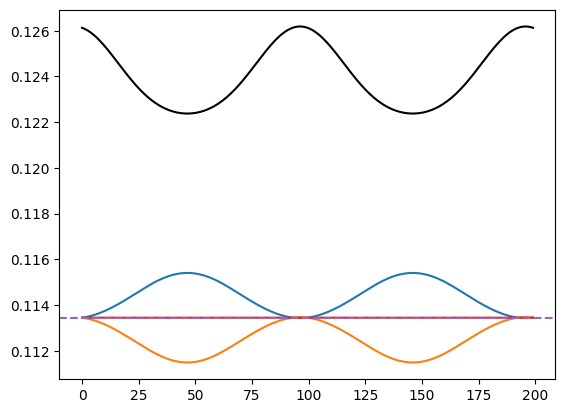

In [19]:
mytorus = pytorus.Torus(Ax,Ay,Cx,Cy)
from shapely import Polygon  

theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,5000)
theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start + np.linspace(0,2*np.pi,200)

plt.figure()
slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)

Ixx = []
Ixy = []
Ix  = []
Jx  = []
for _sx,_sy,id in zip(slice_x,slice_y,np.arange(len(slice_x))):
    
    x_polygon = Polygon([(_x,_px) for _x,_px in zip(_sx[:,0],_sx[:,1])])
    y_polygon = Polygon([(_x,_px) for _x,_px in zip(_sy[:,0],_sy[:,1])])


    # print(x_polygon.area,y_polygon.area,x_polygon.area + y_polygon.area)
    
    Ixx.append(x_polygon.area)
    Ixy.append(-y_polygon.area)
    Ix.append(x_polygon.area - y_polygon.area)

    Jx.append(np.mean(_sx[:,0]**2 + _sx[:,1]**2))

Ixx = np.array(Ixx)/np.pi/2
Ixy = np.array(Ixy)/np.pi/2
Ix  = np.array(Ix)/np.pi/2
Jx  = np.array(Jx)/2
plt.plot(np.arange(len(Ix)),Ix[0] + (Ixx-Ixx[0]),'-',color='C0')
plt.plot(np.arange(len(Ix)),Ix[0] + (Ixy-Ixy[0]),'-',color='C1')
plt.plot(np.arange(len(Ix)),Ix,'-',color='C3')
plt.plot(np.arange(len(Ix)),Jx,'-',color='k')

plt.axhline(mytorus.Ix,ls='--',color='C4')


In [11]:
mytorus.Ix

0.11344918930167401

In [15]:
mytorus.Ix

0.11344972707912353

In [16]:
0.11344972707912353 - 0.11344918930167401

5.377774495163301e-07

In [9]:
Ix-mytorus.Ix

array([ 2.11566008e-07,  2.99449189e-07,  3.92682473e-07,  4.80351815e-07,
        5.50953558e-07,  5.93269909e-07,  5.97298577e-07,  5.55175718e-07,
        4.62020829e-07,  3.16626924e-07,  1.21921403e-07, -1.14866300e-07,
       -3.82374808e-07, -6.65636283e-07, -9.46942872e-07, -1.20700591e-06,
       -1.42632797e-06, -1.58668206e-06, -1.67257620e-06, -1.67257653e-06,
       -1.58037068e-06, -1.39547302e-06, -1.12350383e-06, -7.76012012e-07,
       -3.69850789e-07,  7.38446547e-08,  5.30995568e-07,  9.76126731e-07,
        1.38400093e-06,  1.73121698e-06,  1.99765611e-06,  2.16767993e-06,
        2.23100829e-06,  2.18323467e-06,  2.02596673e-06,  1.76660734e-06,
        1.41781494e-06,  9.96699607e-07,  5.23821460e-07,  2.20627294e-08,
       -4.84557393e-07, -9.72061920e-07, -1.41763541e-06, -1.80064033e-06,
       -2.10349805e-06, -2.31241174e-06, -2.41791666e-06, -2.41524905e-06,
       -2.30452922e-06, -2.09075697e-06, -1.78361930e-06, -1.39711251e-06,
       -9.48983266e-07, -

In [2]:
mytorus.Ix,mytorus.Iy

(0.11344972707912353, 0.09761183168637373)

In [3]:
mytorus.Jx,mytorus.Jy


(0.12408502953631323, 0.10244669368722036)

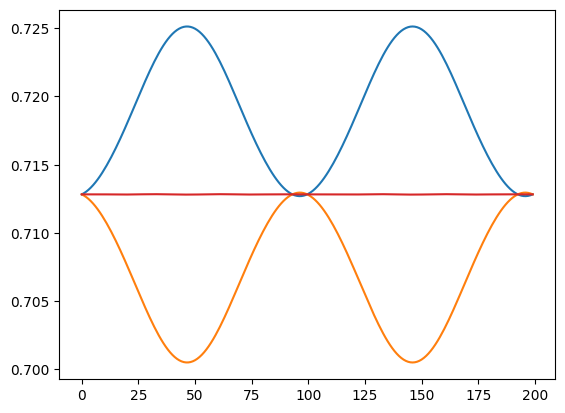

In [79]:
plt.figure()

plt.plot(np.arange(len(Ix)),Ix[0] + (Ixx-Ixx[0]),'-',color='C0')
plt.plot(np.arange(len(Ix)),Ix[0] + (Ixy-Ixy[0]),'-',color='C1')
plt.plot(np.arange(len(Ix)),Ix,'-',color='C3')

plt.axhline()


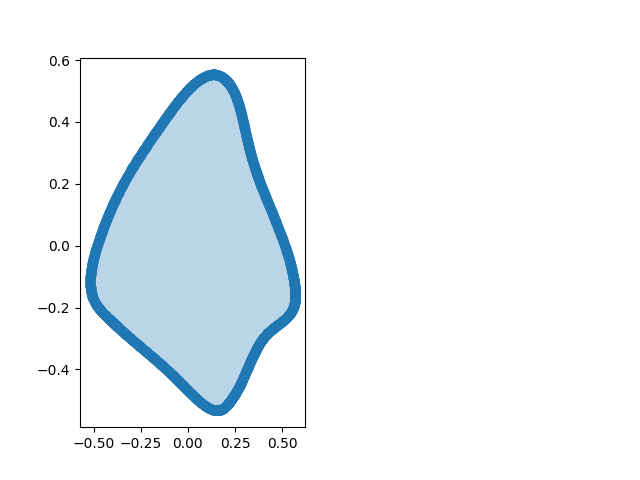

In [49]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.plotting import plot_polygon, plot_points

# from figures import GRAY, RED, SIZE, set_limits

fig = plt.figure()#, figsize=SIZE, dpi=90)

# 3: invalid polygon, ring touch along a line
ax = fig.add_subplot(121)

# ext = [(0, 0), (0, 2), (2, 2), (2, 0), (0, 0)]
# int = [(0.5, 0), (1.5, 0), (1.5, 1), (0.5, 1), (0.5, 0)]
# polygon = Polygon(ext, [int])

plot_polygon(polygon, ax=ax)#, add_points=False, color=RED)
# plot_points(polygon, ax=ax, color=GRAY, alpha=0.7)
plt.show()



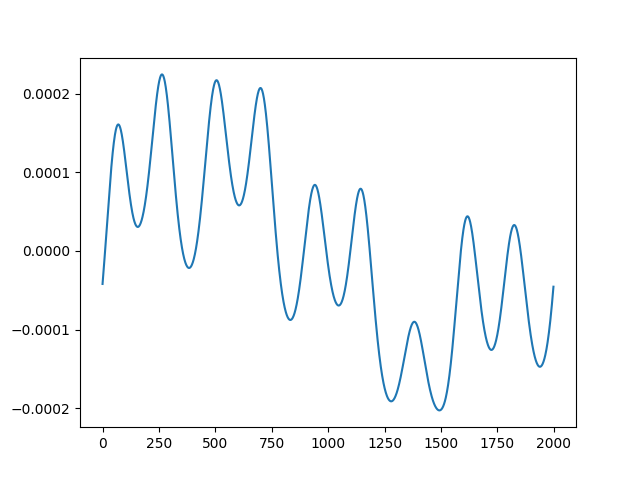

In [25]:
plt.figure()
plt.plot(np.diff(slice_y[:,0]))

(-0.06222909667468761,
 0.15538151229220126,
 -0.09584670131693715,
 0.12176390764995171)

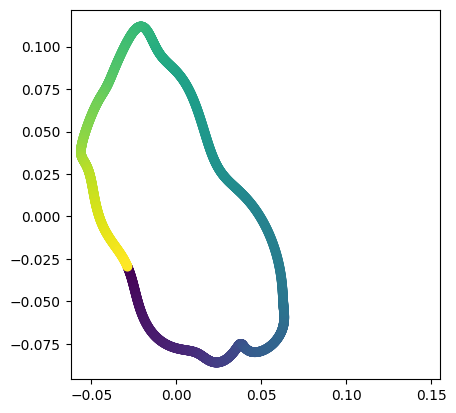

In [14]:

plt.figure()
# plt.plot(slice_y[:,0]-np.mean(slice_y[:,0]),slice_y[:,1]-np.mean(slice_y[:,1]),'-',lw=2,alpha=0.8,zorder=-10)
plt.scatter(slice_y[:,0]-np.mean(slice_y[:,0]),slice_y[:,1]-np.mean(slice_y[:,1]),c=theta_vec)

plt.axis('square')